# Questionnaire Analysis: Transparency, Mental Model & Workload (F1 / F2 / F3)

OpenMATB transparency study (revised, wording-only design) -- the lean post-block
battery plus the final preference debrief. Tests **H1** and **H2** (the main
hypothesis pair) and the single-item workload mechanism check.

- **H1 -- verbose feels more transparent.** Subjective transparency is highest
  under the verbose form (F1), even though the action-relevant content is held
  constant across forms.
- **H2 -- contrastive form improves explicability.** Post-block mental-model
  accuracy is highest under the contrastive forms (F2/F3). H1 and H2 pointing in
  opposite directions is the explainability != explicability crossover.
- **Workload (mechanism check).** Subjective workload is predicted higher under
  F1; it mediates the F1 -> H2 path.

> **Status:** pipeline prepared on pilot data; re-run unchanged once P01-P20 are collected.

## What is measured (after each block; logged by genericscales)

- **Subjective transparency (H1):** three 1-7 agreement items -- "told me what it
  was doing", "hard to keep track" (reverse-keyed), and "amount of information
  felt about right" -- averaged into one transparency score (higher = feels more
  transparent).
- **Mental-model probe (H2):** five sliders scored against ground truth (the aid
  acts on exactly that block's two indicators; 2 misses/block; 2 near-misses/block;
  ~78% reliability). Reported as miss-count, close-call and reliability calibration
  error, recognition accuracy ("did the aid act on indicator X?"), and a normalised
  composite **explicability** score (0-1).
- **Workload (mechanism):** one mental-effort item (1-7).
- **Preference debrief (final, once):** five forced F1<->F3 choices -- the only
  place trust is measured (per-block trust and the full NASA-TLX were dropped).

## Literature

Transparency as levels of agent information: SAT model (Chen et al., 2014;
Mercado et al., 2016; Stowers et al., 2017). Explanation quality and the
explainability/explicability distinction: Miller (2019); the dissociation between
feeling informed and understanding: Wang & Yin (2021), Bansal et al. (2021).
Workload as a single mental-effort rating: Paas (1992). Trust (debrief only)
adapts the trust-in-automation tradition (Jian et al., 2000; Madsen & Gregor, 2000).


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matb_analysis.aggregate import build_metrics_table, build_debrief_table
from matb_analysis.discovery import find_study_sessions, DEFAULT_SESSIONS_DIR
from matb_analysis.validation import validate_sessions

sns.set_theme(style="whitegrid")
FORM_ORDER = ["F1", "F2", "F3"]
OUT = Path.cwd().parent / "outputs"
OUT.mkdir(exist_ok=True)


## 1. Load sessions and questionnaire metrics

In [2]:
sessions = find_study_sessions()
print(f"Reading logs from: {DEFAULT_SESSIONS_DIR}")
print(f"Discovered {len(sessions)} study session(s).")
if not sessions:
    print("No logs yet. Copy the relevant OpenMATB session CSVs into")
    print("analysis/session_logs/ and re-run this notebook.")

table = build_metrics_table(sessions)
q_cols = ["subj_transparency", "workload",
          "mm_rec_accuracy", "mm_misses_error", "mm_closecalls_error",
          "mm_reliability_error", "mm_explicability"]
table[["participant", "form", "block"] + q_cols].round(2)


Reading logs from: C:\Projects\HumanCenteredAI\analysis\session_logs
Discovered 1 study session(s).


,participant,form,block,subj_transparency,workload,mm_rec_accuracy,mm_misses_error,mm_closecalls_error,mm_reliability_error,mm_explicability
0,P03,F2,A,3.98,6.01,1.0,0.01,2.00,18.74,0.87
1,P03,F1,B,6.32,7.00,1.0,2.00,2.00,22.22,0.79
2,P03,F3,C,4.00,4.95,1.0,0.01,0.77,2.09,0.97


## 1b. Session validation

Cross-check each session against the study design before trusting its numbers.

In [3]:
report = validate_sessions(sessions)
n_bad = int((~report["ok"]).sum()) if not report.empty else 0
print(f"{len(report)} session(s) validated; {n_bad} with issues.")
report


1 session(s) validated; 0 with issues.


,session_file,participant,kind,ok,n_blocks,realized,expected,issues
0,26_260602_190745.csv,P03,full,True,3,"[(F2, A), (F1, B), (F3, C)]","[(F2, A), (F1, B), (F3, C)]",


## 2. H1 -- Subjective transparency by form (+ workload mechanism check)

H1 predicts F1 > F2/F3 on transparency (higher = feels more transparent). The
workload mechanism check predicts F1 > F2/F3 on subjective effort.


In [4]:
h1_cols = ["subj_transparency", "workload"]
h1_desc = table.groupby("form")[h1_cols].agg(["mean", "median", "std"]).reindex(FORM_ORDER)
h1_desc.round(2)


subj_transparency            workload           
                  mean median std     mean median std
form                                                 
F1                6.32   6.32 NaN     7.00   7.00 NaN
F2                3.98   3.98 NaN     6.01   6.01 NaN
F3                4.00   4.00 NaN     4.95   4.95 NaN

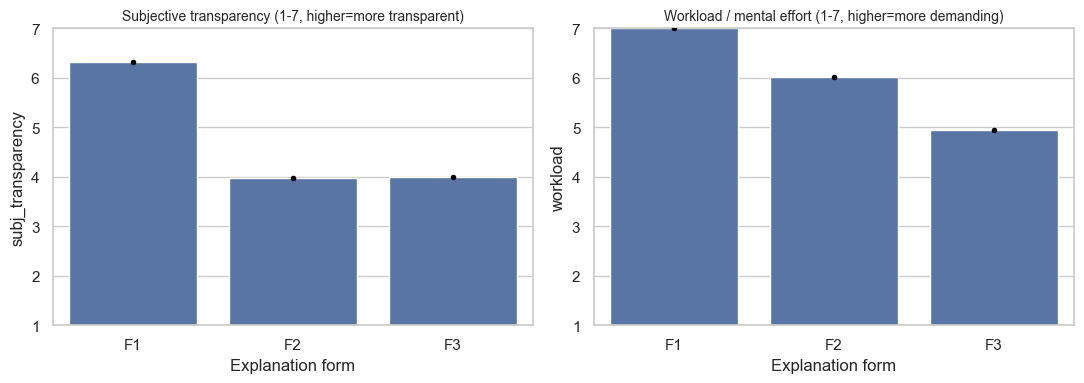

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
specs = [("subj_transparency", "Subjective transparency (1-7, higher=more transparent)"),
         ("workload", "Workload / mental effort (1-7, higher=more demanding)")]
for ax, (col, title) in zip(axes, specs):
    sns.barplot(data=table, x="form", y=col, order=FORM_ORDER, errorbar="sd", ax=ax)
    sns.stripplot(data=table, x="form", y=col, order=FORM_ORDER, color="black", size=4, ax=ax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Explanation form")
    ax.set_ylim(1, 7)
fig.tight_layout()
fig.savefig(OUT / "h1_transparency_workload_by_form.png", dpi=150)
plt.show()


## 3. H2 -- Mental-model accuracy (explicability) by form

H2 predicts F2/F3 > F1 on accuracy/explicability (higher = better) and F2/F3 < F1
on the error measures (lower = better).

In [6]:
h2_cols = ["mm_explicability", "mm_rec_accuracy", "mm_misses_error",
           "mm_closecalls_error", "mm_reliability_error"]
h2_desc = table.groupby("form")[h2_cols].agg(["mean", "median", "std"]).reindex(FORM_ORDER)
h2_desc.round(2)


mm_explicability            mm_rec_accuracy            mm_misses_error  \
                 mean median std            mean median std            mean   
form                                                                          
F1               0.79   0.79 NaN             1.0    1.0 NaN            2.00   
F2               0.87   0.87 NaN             1.0    1.0 NaN            0.01   
F3               0.97   0.97 NaN             1.0    1.0 NaN            0.01   

                mm_closecalls_error            mm_reliability_error             
     median std                mean median std                 mean median std  
form                                                                            
F1     2.00 NaN                2.00   2.00 NaN                22.22  22.22 NaN  
F2     0.01 NaN                2.00   2.00 NaN                18.74  18.74 NaN  
F3     0.01 NaN                0.77   0.77 NaN                 2.09   2.09 NaN

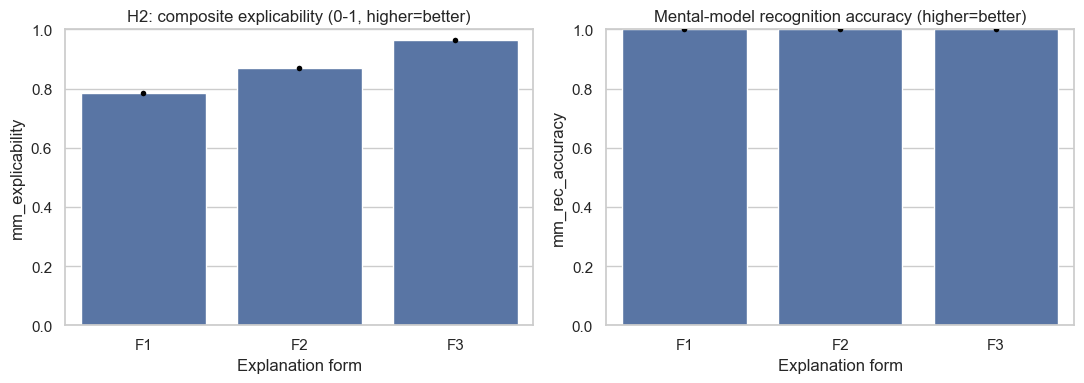

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(
    axes,
    ["mm_explicability", "mm_rec_accuracy"],
    ["H2: composite explicability (0-1, higher=better)",
     "Mental-model recognition accuracy (higher=better)"],
):
    sns.barplot(data=table, x="form", y=col, order=FORM_ORDER, errorbar="sd", ax=ax)
    sns.stripplot(data=table, x="form", y=col, order=FORM_ORDER, color="black", size=4, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Explanation form")
    ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(OUT / "h2_explicability_by_form.png", dpi=150)
plt.show()


## 4. Final preference debrief

Five forced choices on a 1 = Form 1 (continuous) <-> 7 = Form 3 (selective + cue)
scale, one row per participant. Mean > 4 leans toward F3, < 4 toward F1.

,participant,session_file,PREF_q1_most_informative,PREF_q2_most_useful,PREF_q3_most_trusted,PREF_q4_least_distracting,PREF_q5_self_chosen
0,P03,26_260602_190745.csv,1.0,7.0,7.0,7.0,7.0


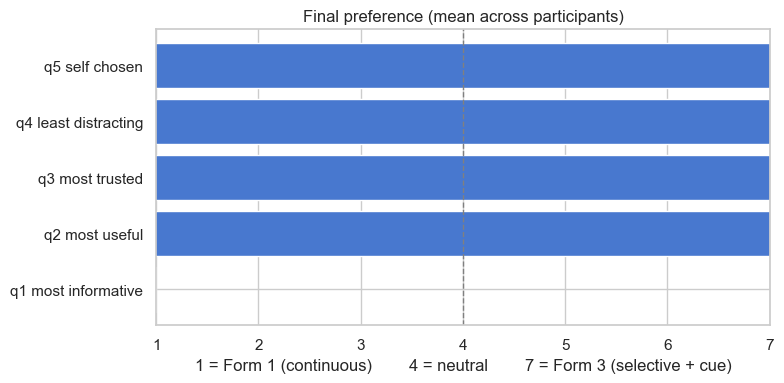

In [8]:
debrief = build_debrief_table(sessions)
pref_cols = ["PREF_q1_most_informative", "PREF_q2_most_useful", "PREF_q3_most_trusted",
             "PREF_q4_least_distracting", "PREF_q5_self_chosen"]
display(debrief.round(2))

if not debrief.empty:
    means = debrief[pref_cols].mean()
    fig, ax = plt.subplots(figsize=(8, 4))
    labels = [c.replace("PREF_", "").replace("_", " ") for c in pref_cols]
    ax.barh(labels, means.values, color="#4878CF")
    ax.axvline(4, color="grey", ls="--", lw=1)
    ax.set_xlim(1, 7)
    ax.set_xlabel("1 = Form 1 (continuous)        4 = neutral        7 = Form 3 (selective + cue)")
    ax.set_title("Final preference (mean across participants)")
    fig.tight_layout()
    fig.savefig(OUT / "debrief_preferences.png", dpi=150)
    plt.show()


## 5. Summary (H1 + H2) and the explainability != explicability crossover

The crossover prediction: F1 wins on *felt* transparency (H1) while F2/F3 win on
*actual* understanding (H2). Workload is reported alongside as the mechanism check.


In [9]:
summary = (table.groupby("form")[
              ["subj_transparency", "workload", "mm_rec_accuracy", "mm_explicability"]]
              .mean().reindex(FORM_ORDER).round(2))
summary.to_csv(OUT / "h1_h2_summary_by_form.csv")
summary


,subj_transparency,workload,mm_rec_accuracy,mm_explicability
form,,,,
F1,6.32,7.00,1.0,0.79
F2,3.98,6.01,1.0,0.87
F3,4.00,4.95,1.0,0.97


## 6. Inferential tests -- to add when N is adequate

Deliberately omitted now (small pilot N). When P01-P20 are collected, add
within-subject tests across the three forms per measure (e.g. Friedman omnibus +
Wilcoxon signed-rank post-hoc), and test the H1xH2 crossover explicitly. The tidy
table above is the input.
